#**1. Download Dependencies**

In [3]:
!pip install transformers datasets torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!pip install -U transformers

# **2. Import Libraries**

In [5]:
import pandas as pd
import numpy as np
import re

# **3. Loading, Exploring, and Preprocessing the Data**

In [6]:
df=pd.read_csv('train.csv')

## **3.1 Exploring Data**

In [7]:
df

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [8]:
df['target'].value_counts()

,count
target,
0,4342
1,3271


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


## **3.2 Drop Unnecessary Columns**

In [10]:
df=df.drop(['id','location'],axis=1)

In [11]:
df = df.reset_index(drop=True)

In [12]:
df

,keyword,text,target
0,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,NaN,Forest fire near La Ronge Sask. Canada,1
2,NaN,All residents asked to 'shelter in place' are ...,1
3,NaN,"13,000 people receive #wildfires evacuation or...",1
4,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...
7608,NaN,Two giant cranes holding a bridge collapse int...,1
7609,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,NaN,Police investigating after an e-bike collided ...,1


## **3.3 Handle Missing Values**

In [13]:
df['keyword']=df['keyword'].fillna('')
df.sample(5)

,keyword,text,target
1492,catastrophe,@mark_argent I haven't watched that one yet. J...,0
4586,injuries,The injuries are starting!!! Please @dallascow...,0
3566,famine,when things become terrible more than the grea...,0
6849,trauma,games that I really hope to see in AGDQ: Traum...,0
6038,seismic,#OilandGas Exploration Takes Seismic Shift in ...,1


## **3.4 Text Normalization**

In [14]:
# lowercase every thing
df['keyword']=df['keyword'].str.lower()
df['text']=df['text'].str.lower()

## **3.5 Merge Text and Keyword**

In [15]:
df['text']=df['text']+' '+ df['keyword']
df=df.drop('keyword',axis=1)
df = df.reset_index(drop=True)
df.sample(5)

,text,target
4358,san jose mercury: governor brown allows parole...,0
1072,@daniglasgow45 happy birthday big d!!! i miss ...,0
3314,30 seconds for my bitches to evacuate ?????? e...,0
6107,so happy to be exercised of the demon of @att....,0
1945,when you're 5 hours late for curfew and have t...,0


##**3.6 Advanced Text Cleaning**

In [16]:
def preprocess_text(text):
  text=re.sub('https?://\S+|www\.\S+','',text) # remove url
  # remove punctuation
  text=re.sub('[^a-zA-Z0-9]',' ',text)
  # remove extra spaces
  text=re.sub('\s+',' ',text)
  return text

In [17]:
df['text'].apply(preprocess_text)

,text
0,our deeds are the reason of this earthquake ma...
1,forest fire near la ronge sask canada
2,all residents asked to shelter in place are be...
3,13 000 people receive wildfires evacuation ord...
4,just got sent this photo from ruby alaska as s...
...,...
7608,two giant cranes holding a bridge collapse int...
7609,aria ahrary thetawniest the out of control wi...
7610,m1 94 01 04 utc 5km s of volcano hawaii
7611,police investigating after an e bike collided ...


# **4. Model and Tokenizer Loading**

In [18]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

In [19]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-large')
model = RobertaForSequenceClassification.from_pretrained('roberta-large', num_labels=2)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
x = df['text']
y = df['target']
x.shape

(7613,)

# **5. Prepare Train/Validation Splits**

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


In [24]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((6090,), (6090,), (1523,), (1523,))

# **6. Tokenize My Data**

In [25]:
train_encodings = tokenizer(X_train.tolist(), padding=True, truncation=True, return_tensors='pt')
test_encodings = tokenizer(X_test.tolist(), padding=True, truncation=True, return_tensors='pt')


# **7. Build a Dataset class**

In [26]:
from torch.utils.data import Dataset

In [27]:
class twitter_dataset(Dataset):
  def __init__(self,encodings,labels):
    self.encodings=encodings
    self.labels=labels

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, index) :
    item = {key:val[index] for key,val in self.encodings.items()}
    item['labels'] = self.labels[index]
    return item

In [28]:
dataset=twitter_dataset(train_encodings,y_train)
test_dataset=twitter_dataset(test_encodings,y_test)

In [29]:
dataset[5]

{'input_ids': tensor([    0, 34427,  1580,   128,  3865, 39830,  1474,   108,    25,    31,
           475,   298, 21713,    35,  8196,  4113,   493,  4751,    35,  3725,
             8,     5,  1232,     9,   167,    54,    58,   734,  2054,   640,
            90,     4,   876,    73, 28831,  4283,  1178, 20378,  1343, 19562,
         22520,     2,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

# **8. Defining TrainingArguments**

In [41]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [30]:
from transformers import TrainingArguments, Trainer # import TrainingArguments and Trainer

In [31]:
training_args = TrainingArguments(
    output_dir="./results",
    run_name="bert-finetune-disaster",
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=100,
    logging_steps=100,
    save_steps=100,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    gradient_checkpointing=True,
    fp16=True
)


# **9. Trainer Prepration**


In [32]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    precision=precision_score(labels, preds)
    recall=recall_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }


In [33]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


<ipython-input-33-59fbfaa19476>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


# **10. Train the model**

In [40]:
import wandb
wandb.init(mode="disabled")

In [42]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
100,0.302000,0.622524,0.801707,0.775298,0.749640,0.802773
200,0.473100,0.469951,0.839790,0.812308,0.811060,0.813559
300,0.450700,0.380313,0.847012,0.812550,0.850168,0.778120
400,0.412400,0.507679,0.816809,0.788476,0.776119,0.801233
500,0.298600,0.509699,0.845043,0.811802,0.841322,0.784284
600,0.321900,0.445306,0.840446,0.801956,0.851211,0.758089
700,0.331400,0.466725,0.826658,0.796923,0.795699,0.798151
800,0.279700,0.606321,0.820749,0.795199,0.774854,0.816641
900,0.233000,0.607966,0.829284,0.799073,0.801550,0.796610


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
100,0.302000,0.622524,0.801707,0.775298,0.749640,0.802773
200,0.473100,0.469951,0.839790,0.812308,0.811060,0.813559
300,0.450700,0.380313,0.847012,0.812550,0.850168,0.778120
400,0.412400,0.507679,0.816809,0.788476,0.776119,0.801233
500,0.298600,0.509699,0.845043,0.811802,0.841322,0.784284
600,0.321900,0.445306,0.840446,0.801956,0.851211,0.758089
700,0.331400,0.466725,0.826658,0.796923,0.795699,0.798151
800,0.279700,0.606321,0.820749,0.795199,0.774854,0.816641
900,0.233000,0.607966,0.829284,0.799073,0.801550,0.796610
1000,0.235500,0.586108,0.835194,0.802518,0.819936,0.785824


TrainOutput(global_step=1143, training_loss=0.32273128172439747, metrics={'train_runtime': 1733.243, 'train_samples_per_second': 10.541, 'train_steps_per_second': 0.659, 'total_flos': 2859900774781680.0, 'train_loss': 0.32273128172439747, 'epoch': 3.0})

# **11. Evaluation**

In [43]:
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)

Evaluation Results: {'eval_loss': 0.3803134560585022, 'eval_accuracy': 0.8470124753775443, 'eval_f1': 0.8125502815768303, 'eval_precision': 0.8501683501683501, 'eval_recall': 0.7781201848998459, 'eval_runtime': 7.5659, 'eval_samples_per_second': 201.297, 'eval_steps_per_second': 12.688, 'epoch': 3.0}


# **12. Visulaze My Metrics**

## **12.1 Show Training and Validation Loss Curve**

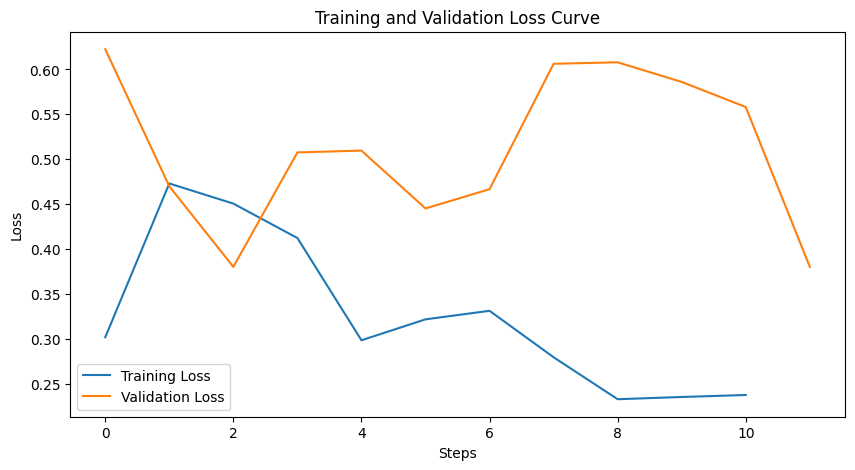

In [45]:
import matplotlib.pyplot as plt


train_losses = trainer.state.log_history


train_loss = [entry['loss'] for entry in train_losses if 'loss' in entry]
eval_loss = [entry['eval_loss'] for entry in train_losses if 'eval_loss' in entry]


plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.show()


## **12.2 Showing precision, recall, and f1 score Graphs**

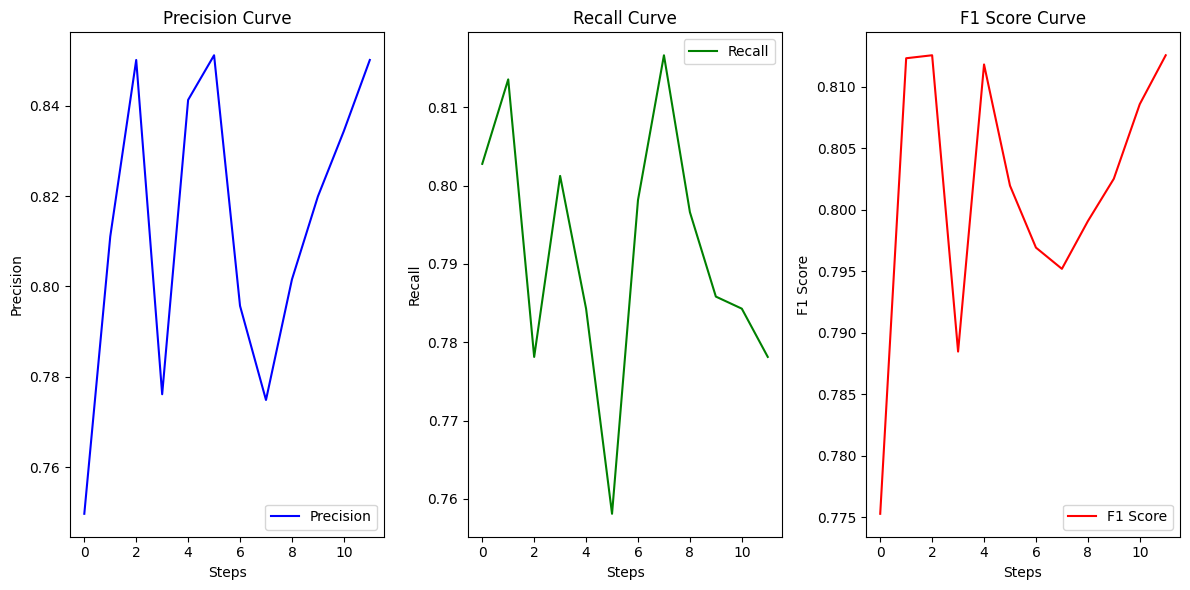

In [48]:
# Extract metrics for precision, recall, and f1 score
precision_values = [entry['eval_precision'] for entry in train_losses if 'eval_precision' in entry]
recall_values = [entry['eval_recall'] for entry in train_losses if 'eval_recall' in entry]
f1_values = [entry['eval_f1'] for entry in train_losses if 'eval_f1' in entry]

# Plotting
plt.figure(figsize=(12, 6))

# Plot Precision
plt.subplot(1, 3, 1)
plt.plot(precision_values, label='Precision', color='blue')
plt.xlabel('Steps')
plt.ylabel('Precision')
plt.title('Precision Curve')
plt.legend()

# Plot Recall
plt.subplot(1, 3, 2)
plt.plot(recall_values, label='Recall', color='green')
plt.xlabel('Steps')
plt.ylabel('Recall')
plt.title('Recall Curve')
plt.legend()

# Plot F1 Score
plt.subplot(1, 3, 3)
plt.plot(f1_values, label='F1 Score', color='red')
plt.xlabel('Steps')
plt.ylabel('F1 Score')
plt.title('F1 Score Curve')
plt.legend()

plt.tight_layout()
plt.show()